# Plot Gallery

A reference notebook of every plotting helper in `assyst.plot`.  It loads a
small pre-generated Cu–Zn dataset (~1300 structures) so each example runs
in a second or two — feel free to swap in your own list of `ase.Atoms`.

The plots below are grouped into four families:

- **Overview** — every plot at a glance,
- **Structural** — cell-related quantities (volume, lattice parameters,
  angles, aspect ratios, sizes),
- **Composition** — element concentrations,
- **Distances / neighbours** — bond distances and radial distributions,
- **Energy** — energy histograms and energy-vs-X scatter/hexbin plots.

Each example also notes the most useful keyword arguments.

## Setup

In [1]:
import pickle
import matplotlib.pyplot as plt
import assyst.plot as aplot

with open("data/plot_gallery.pkl", "rb") as f:
    structures = pickle.load(f)

print(f"Loaded {len(structures)} structures")

Loaded 1345 structures


## Overview

Every plot at default settings, side by side.

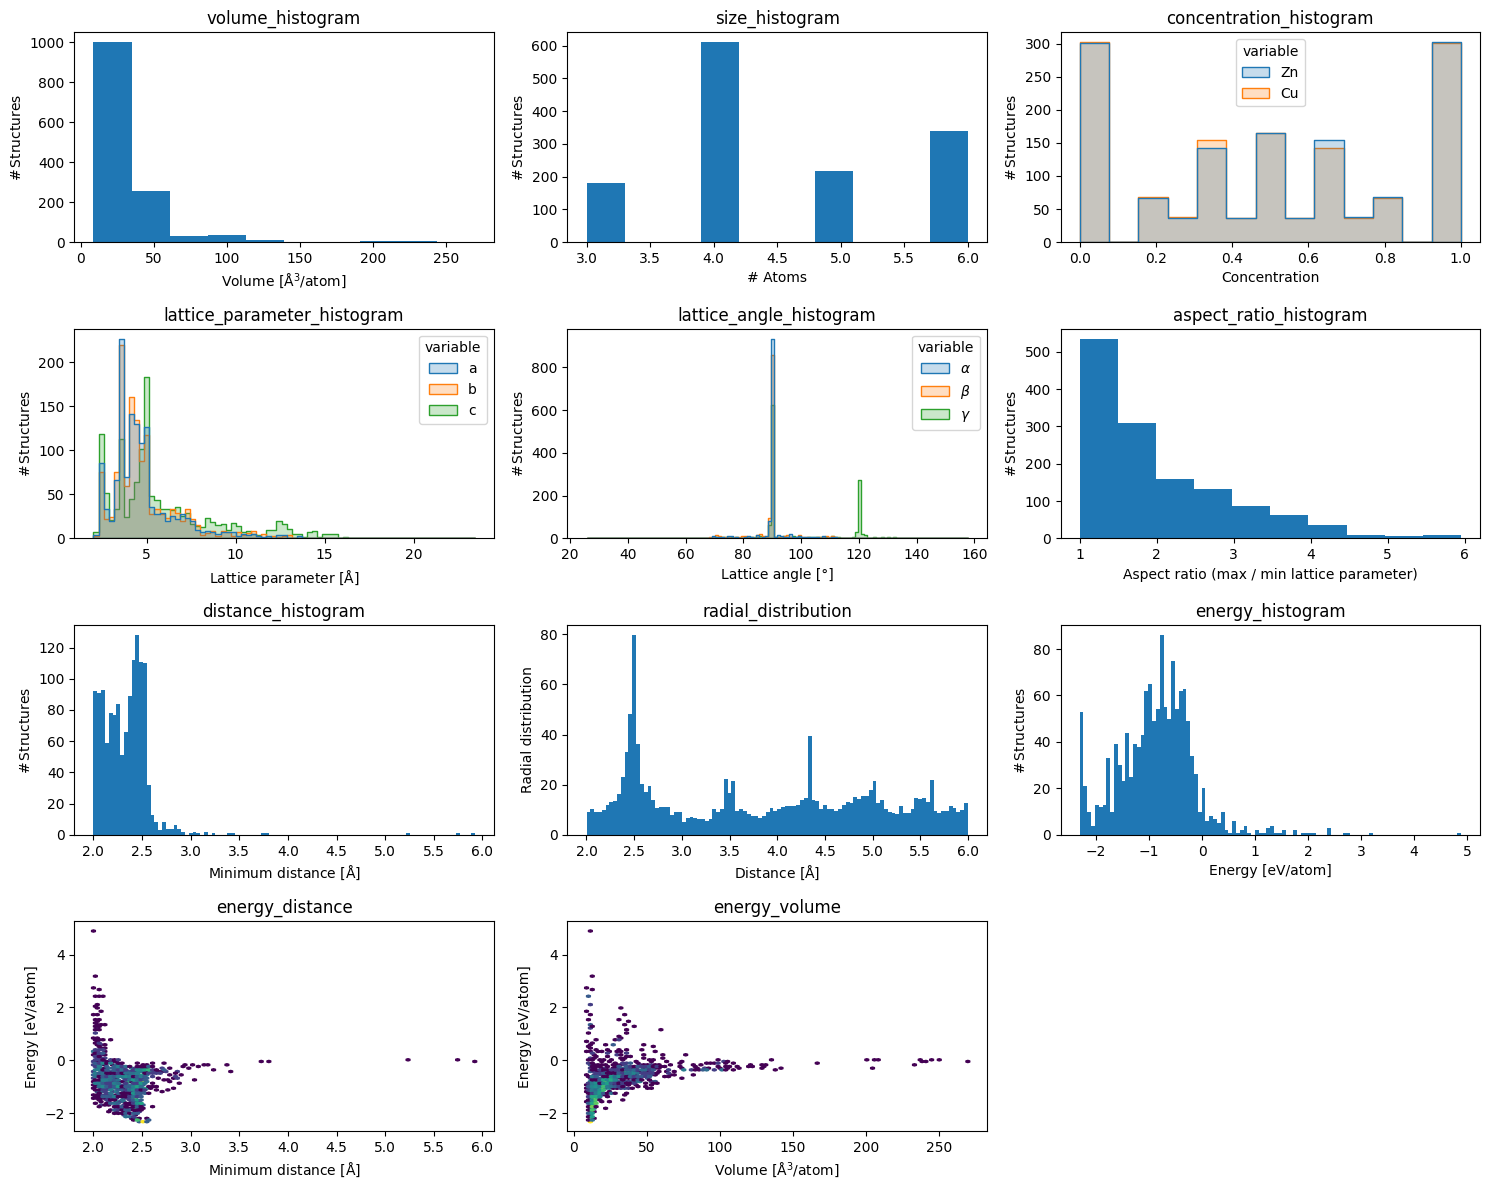

In [2]:
fig = plt.figure(figsize=(15, 12))

plots = [
    ('volume_histogram',            aplot.volume_histogram),
    ('size_histogram',              aplot.size_histogram),
    ('concentration_histogram',     aplot.concentration_histogram),
    ('lattice_parameter_histogram', aplot.lattice_parameter_histogram),
    ('lattice_angle_histogram',     aplot.lattice_angle_histogram),
    ('aspect_ratio_histogram',      aplot.aspect_ratio_histogram),
    ('distance_histogram',          aplot.distance_histogram),
    ('radial_distribution',         aplot.radial_distribution),
    ('energy_histogram',            aplot.energy_histogram),
    ('energy_distance',             aplot.energy_distance),
    ('energy_volume',               aplot.energy_volume),
]

for i, (name, fn) in enumerate(plots, start=1):
    plt.subplot(4, 3, i)
    plt.title(name)
    fn(structures)

plt.tight_layout()

## Structural

### `volume_histogram`

Per-atom cell volume.  `bins` controls resolution, `density=True` normalises
to a probability density, `color` picks the bar colour.

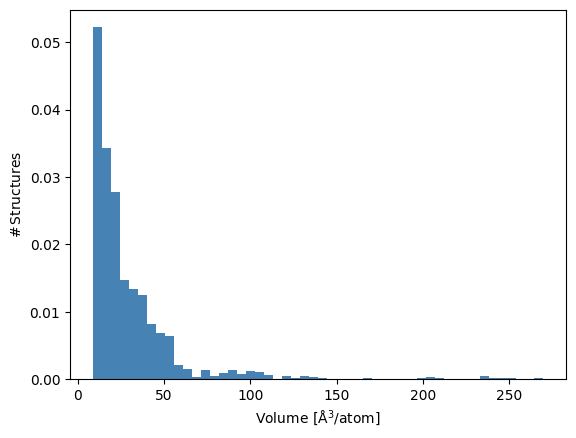

In [3]:
aplot.volume_histogram(structures, bins=50, color='steelblue', density=True);

### `size_histogram`

Number of atoms per structure.  `rwidth` adds a gap between bars; useful
when bins align to integer counts.

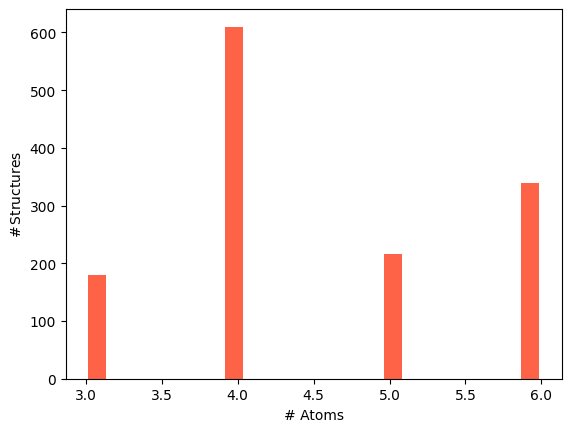

In [4]:
aplot.size_histogram(structures, bins=20, color='tomato', rwidth=0.8);

### `lattice_parameter_histogram`

Lattice parameters $a$, $b$, $c$ overlaid in one panel.  `kde=True` adds a
kernel-density estimate; `alpha` tames overlap between the three series.

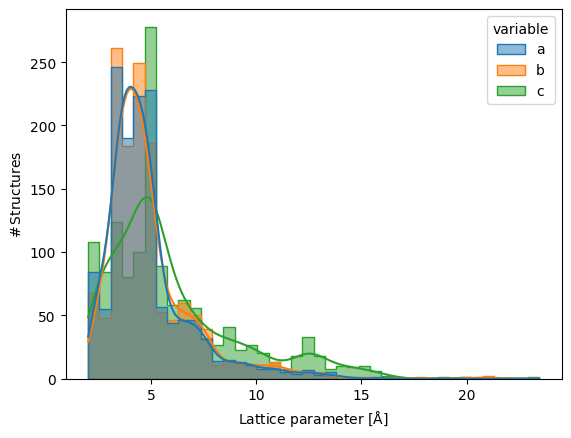

In [5]:
aplot.lattice_parameter_histogram(structures, bins=40, kde=True, alpha=0.5);

### `lattice_angle_histogram`

Lattice angles $\alpha$, $\beta$, $\gamma$.  `kde=True` is especially
helpful here — angles cluster sharply near 90°.

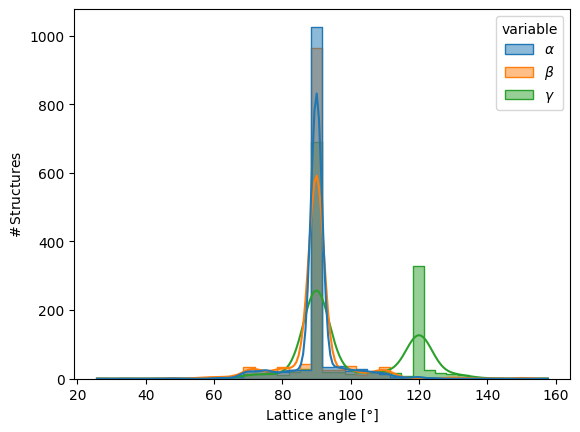

In [6]:
aplot.lattice_angle_histogram(structures, bins=40, kde=True, alpha=0.5);

### `aspect_ratio_histogram`

Ratio of longest to shortest lattice vector — a quick check for very
elongated cells.  `histtype='step'` draws an unfilled outline; useful when
overlaying multiple datasets.

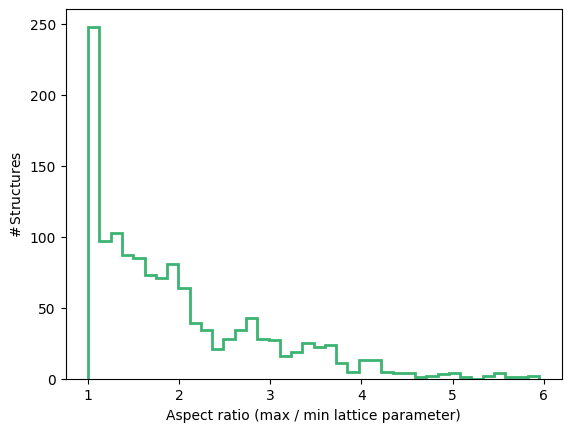

In [7]:
aplot.aspect_ratio_histogram(structures, bins=40, color='mediumseagreen', histtype='step', linewidth=2);

## Composition

### `concentration_histogram`

Per-structure concentration of each element.  Pass `elements=` to restrict
which species are shown.

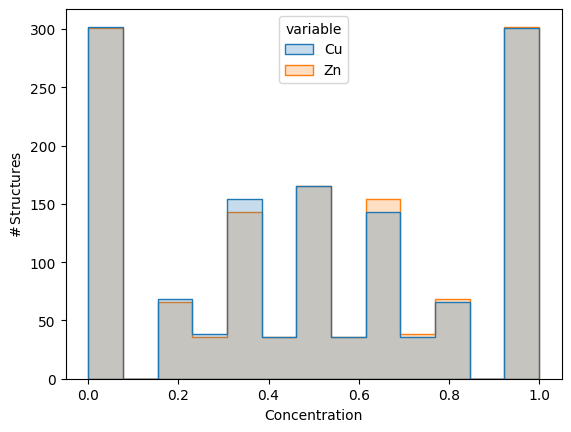

In [8]:
aplot.concentration_histogram(structures, elements=['Cu', 'Zn']);

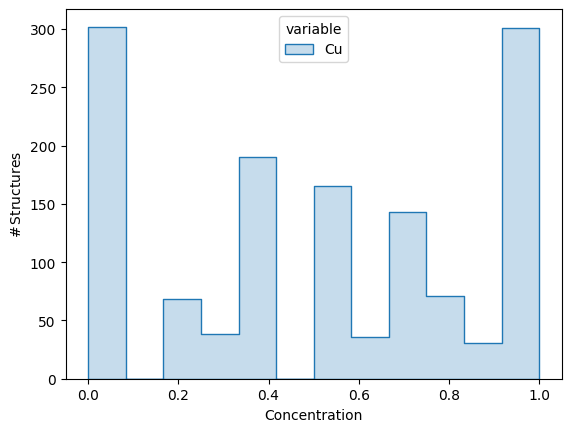

In [9]:
aplot.concentration_histogram(structures, elements=['Cu']);

## Distances and neighbours

### `distance_histogram`

Per-structure neighbour-distance summary.  By default the *minimum* neighbour
distance per structure is binned; pass `reduce='mean'` for the mean or any
custom callable.  `rmax` sets the neighbour cutoff.

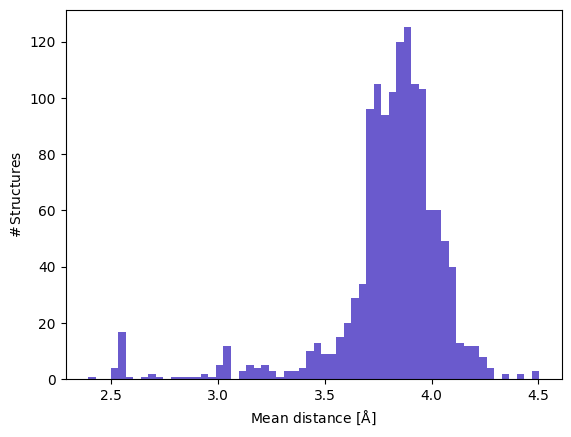

In [10]:
aplot.distance_histogram(structures, rmax=5.0, reduce='mean', bins=60, color='slateblue');

### `radial_distribution`

All neighbour distances pooled together and weighted by 1/(4πr²) — useful
for spotting preferred bond lengths.  Increase `rmax` *and* `bins` together
for finer resolution at larger distances.

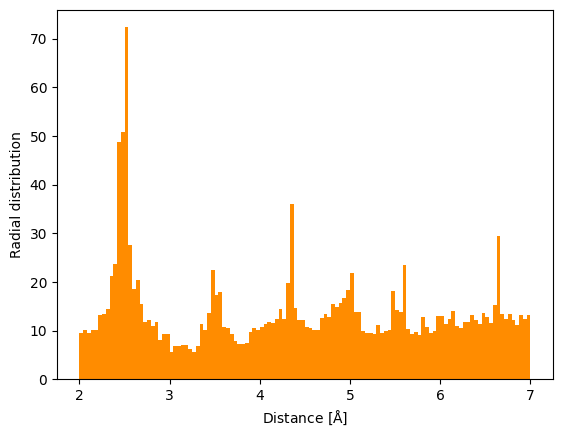

In [11]:
aplot.radial_distribution(structures, rmax=7.0, bins=120, color='darkorange');

## Energy

All energy plots require an attached calculator (e.g. a
`SinglePointCalculator` from a relaxation or an ASE calculator).  Use
`density=True` when comparing datasets of different sizes.

### `energy_histogram`

Energy per atom.  `density=True` normalises to a probability density; `log=True`
switches the y-axis to log scale, which is useful when a handful of high-energy
outliers would otherwise compress the main peak.

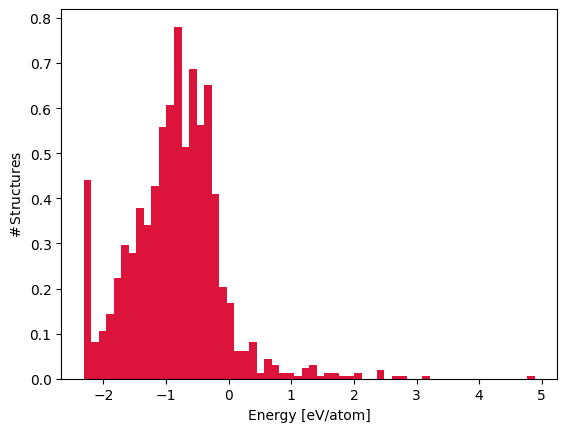

In [12]:
aplot.energy_histogram(structures, bins=60, color='crimson', density=True);

In [ ]:
aplot.energy_histogram(structures, bins=60, color='crimson', log=True);

### `energy_distance`

Energy per atom against neighbour distance.  With ≥ 1000 structures the
function automatically switches from a scatter to `hexbin`.

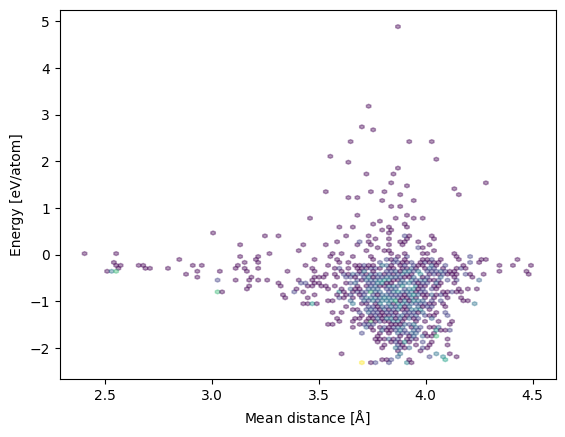

In [13]:
aplot.energy_distance(structures, reduce='mean', rmax=5.0, alpha=0.4);

### `energy_volume`

Energy per atom against per-atom volume.  Same hexbin behaviour for large
datasets.

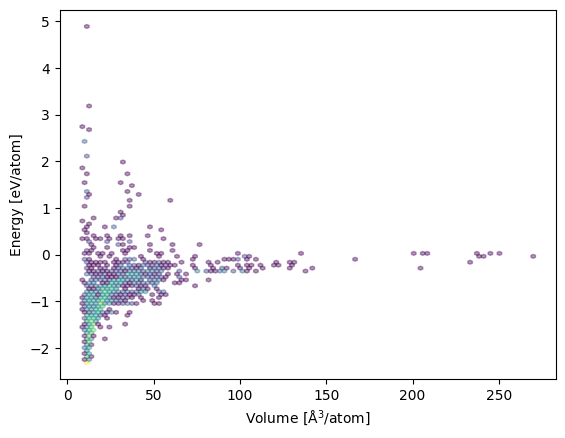

In [14]:
aplot.energy_volume(structures, alpha=0.4);